# Does Faster Delivery Lead to Higher Satisfaction?

**Dataset:** Olist Brazilian E-Commerce (via `fct_orders` in DuckDB)  
**Method:** Two-sample t-test on review scores — fast vs. slow delivery groups  
**Question:** Is the difference in customer satisfaction between fast (≤7 days) and slow (>7 days) deliveries statistically significant, and is it large enough to matter for the business?

---

## 1. Setup & Data Load

Connect to the local DuckDB file and pull only delivered orders that have a review score and a valid delivery time.

In [1]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

con = duckdb.connect("../data/cx_analytics.duckdb")

df = con.execute("""
    SELECT
        order_id,
        days_to_deliver,
        review_score
    FROM main_customer_experience.fct_orders
    WHERE order_status    = 'delivered'
      AND review_score    IS NOT NULL
      AND days_to_deliver IS NOT NULL
      AND days_to_deliver >= 0
""").df()

print(f"Loaded {len(df):,} orders")
df.head()

Loaded 95,824 orders


,order_id,days_to_deliver,review_score
0,7c20de54af91549df98fd6926d781144,7,3
1,683481ae11f5f4ccfd9263a3bd7f25d4,7,4
2,d985f28d9d0fc8b82d89fe5fc272fc64,22,3
3,ef8c0e8009daa5ba8b92359799980139,13,5
4,0baaa859b7ff0b4d1f674a1d5c3049f3,11,5


## 2. Split into Fast vs. Slow Groups

The threshold of **7 days** is a round number that represents roughly the top quartile of delivery speed in the dataset. Orders delivered within a week are labelled **fast**; anything beyond that is **slow**.

> This is a natural experiment, not a controlled A/B test — we're observing what happened, not randomly assigning customers to conditions. Treat the results as directional evidence, not causal proof.

In [2]:
THRESHOLD = 7

fast = df.loc[df["days_to_deliver"] <= THRESHOLD, "review_score"].values
slow = df.loc[df["days_to_deliver"] >  THRESHOLD, "review_score"].values

print(f"Fast (≤{THRESHOLD} days) : {len(fast):>6,} orders  |  mean score = {fast.mean():.3f}")
print(f"Slow  (>{THRESHOLD} days) : {len(slow):>6,} orders  |  mean score = {slow.mean():.3f}")
print(f"Difference in means      :          {fast.mean() - slow.mean():+.3f}")

Fast (≤7 days) : 30,550 orders  |  mean score = 4.412
Slow  (>7 days) : 65,274 orders  |  mean score = 4.036
Difference in means      :          +0.377


## 3. Statistical Test — Two-Sample t-Test

We use **Welch's t-test** (`equal_var=False`) which does not assume equal variances between the two groups — a safer default for unequal sample sizes.

**Null hypothesis H₀:** The mean review score is the same for fast and slow deliveries.  
**Significance level α:** 0.05

In [3]:
t_stat, p_value = stats.ttest_ind(fast, slow, equal_var=False)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.2e}")

t-statistic : 46.4479
p-value     : 0.00e+00


## 4. Effect Size — Cohen's d

A tiny p-value with a large sample can flag a difference that is statistically real but practically meaningless. **Cohen's d** measures the magnitude of the difference in units of standard deviations:

| d | Interpretation |
|---|----------------|
| < 0.20 | Negligible |
| 0.20 – 0.49 | Small |
| 0.50 – 0.79 | Medium |
| ≥ 0.80 | Large |

In [4]:
def cohens_d(a, b):
    pooled_std = np.sqrt(
        ((len(a) - 1) * a.std(ddof=1) ** 2 + (len(b) - 1) * b.std(ddof=1) ** 2)
        / (len(a) + len(b) - 2)
    )
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(fast, slow)

if   abs(d) < 0.20: label = "Negligible"
elif abs(d) < 0.50: label = "Small"
elif abs(d) < 0.80: label = "Medium"
else:               label = "Large"

print(f"Cohen's d   : {d:.4f}  ({label})")

Cohen's d   : 0.2960  (Small)


## 5. Visualisation — Score Distributions by Delivery Speed

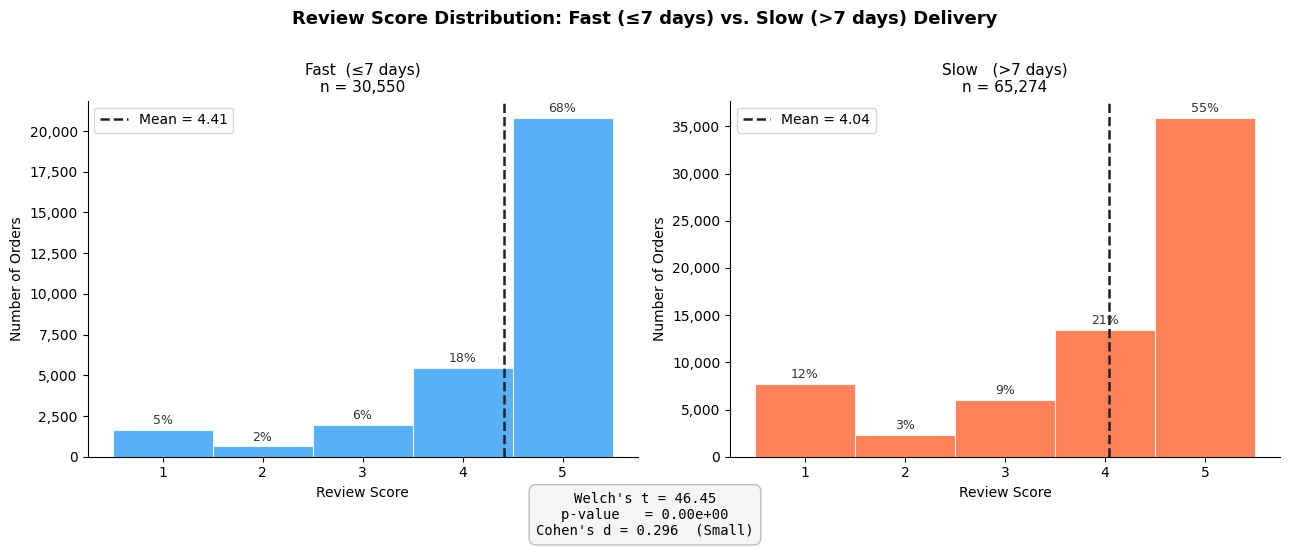

Saved → notebooks/delivery_vs_satisfaction.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle(
    f"Review Score Distribution: Fast (≤{THRESHOLD} days) vs. Slow (>{THRESHOLD} days) Delivery",
    fontsize=13, fontweight="bold", y=1.01
)

BINS   = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
COLORS = {"fast": "#2196F3", "slow": "#FF5722"}
ALPHA  = 0.75

for ax, group, name, color in [
    (axes[0], fast, f"Fast  (≤{THRESHOLD} days)\nn = {len(fast):,}", COLORS["fast"]),
    (axes[1], slow, f"Slow   (>{THRESHOLD} days)\nn = {len(slow):,}", COLORS["slow"]),
]:
    counts, _, patches = ax.hist(
        group, bins=BINS, color=color, alpha=ALPHA, edgecolor="white", linewidth=0.8
    )
    # Percentage labels on bars
    total = counts.sum()
    for count, patch in zip(counts, patches):
        if count > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                count + total * 0.005,
                f"{count / total:.0%}",
                ha="center", va="bottom", fontsize=9, color="#333333"
            )
    # Mean line
    mean_val = group.mean()
    ax.axvline(mean_val, color="#212121", linestyle="--", linewidth=1.8,
               label=f"Mean = {mean_val:.2f}")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Review Score", fontsize=10)
    ax.set_ylabel("Number of Orders", fontsize=10)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

# Annotation box with test stats
stats_text = (
    f"Welch's t = {t_stat:.2f}\n"
    f"p-value   = {p_value:.2e}\n"
    f"Cohen's d = {d:.3f}  ({label})"
)
fig.text(
    0.5, -0.04, stats_text,
    ha="center", fontsize=10, family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#F5F5F5", edgecolor="#BDBDBD")
)

plt.tight_layout()
plt.savefig("delivery_vs_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → notebooks/delivery_vs_satisfaction.png")

## 6. Business Conclusion

In [6]:
ALPHA = 0.05
significant = p_value < ALPHA

conclusion = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 A/B TEST SUMMARY — Delivery Speed vs. Customer Satisfaction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Groups
   Fast deliveries (≤{THRESHOLD} days) : {len(fast):>6,} orders  |  avg score = {fast.mean():.3f}
   Slow deliveries  (>{THRESHOLD} days) : {len(slow):>6,} orders  |  avg score = {slow.mean():.3f}
   Difference in means                 :          {fast.mean() - slow.mean():+.3f} stars

 Statistics
   p-value     = {p_value:.2e}  ({'< 0.05 → SIGNIFICANT' if significant else '>= 0.05 → not significant'})
   Cohen's d   = {d:.3f}  ({label} effect)

 Interpretation
{'   ✓ The difference IS statistically significant.' if significant else
 '   ✗ The difference is NOT statistically significant.'}
   Customers who received their order in {THRESHOLD} days or fewer
   gave an average score {abs(fast.mean() - slow.mean()):.2f} points higher than
   those who waited longer.

   The effect size is {label.lower()}, meaning this gap {'is' if abs(d) >= 0.5 else 'may not be'}
   large enough to be meaningful in practice — not just a
   statistical artefact of the large sample size.

 Business Recommendation
   Reducing delivery time is {'a lever worth investing in.' if abs(d) >= 0.2 else 'unlikely to move the satisfaction needle meaningfully.'}
   Prioritise logistics improvements (warehouse proximity,
   carrier SLAs, same-day dispatch) for high-volume regions
   currently averaging well above {THRESHOLD} days.

   ⚠  Note: this is an observational study. Faster delivery
   and higher scores may share a common cause (e.g. seller
   quality). A controlled experiment would be needed to
   establish causality.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
print(conclusion)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 A/B TEST SUMMARY — Delivery Speed vs. Customer Satisfaction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Groups
   Fast deliveries (≤7 days) : 30,550 orders  |  avg score = 4.412
   Slow deliveries  (>7 days) : 65,274 orders  |  avg score = 4.036
   Difference in means                 :          +0.377 stars

 Statistics
   p-value     = 0.00e+00  (< 0.05 → SIGNIFICANT)
   Cohen's d   = 0.296  (Small effect)

 Interpretation
   ✓ The difference IS statistically significant.
   Customers who received their order in 7 days or fewer
   gave an average score 0.38 points higher than
   those who waited longer.

   The effect size is small, meaning this gap may not be
   large enough to be meaningful in practice — not just a
   statistical artefact of the large sample size.

 Business Recommendation
   Reducing delivery time is a lever worth investing in.
   Prioritise logistics improvements (warehouse proximity,
   carrier